# PROJECT 3

In [2]:
# Importation of module 

import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn import ensemble
import kmapper as km
import umap
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from kmapper import jupyter # Creates custom CSS full-size Jupyter screen
#import aux
from ripser import ripser
from persim import plot_diagrams
import networkx as nx

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.neighbors import NearestNeighbors

import kmapper as km
from kmapper.cover import Cover


In [3]:
#import pandas as pd
#import numpy as np

df = pd.read_csv('pd_speech_features.csv', header=None)


df.columns = df.iloc[1]


df = df.iloc[2:].reset_index(drop=True)


for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')


df = df.dropna()
df.head()

1,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,0,1,0.85247,0.71826,0.57227,240,239,0.008064,0.000087,0.00218,...,1.5620,2.6445,3.8686,4.2105,5.1221,4.4625,2.6202,3.0004,18.9405,1
1,0,1,0.76686,0.69481,0.53966,234,233,0.008258,0.000073,0.00195,...,1.5589,3.6107,23.5155,14.1962,11.0261,9.5082,6.5245,6.3431,45.1780,1
2,0,1,0.85083,0.67604,0.58982,232,231,0.008340,0.000060,0.00176,...,1.5643,2.3308,9.4959,10.7458,11.0177,4.8066,2.9199,3.1495,4.7666,1
3,1,0,0.41121,0.79672,0.59257,178,177,0.010858,0.000183,0.00419,...,3.7805,3.5664,5.2558,14.0403,4.2235,4.6857,4.8460,6.2650,4.0603,1
4,1,0,0.32790,0.79782,0.53028,236,235,0.008162,0.002669,0.00535,...,6.1727,5.8416,6.0805,5.7621,7.7817,11.6891,8.2103,5.0559,6.1164,1


In [4]:
feature_names = [c for c in df.columns if c not in ["id", "gender", "class"]]

In [5]:
# df["diagnosis"] = df["diagnosis"].apply(lambda x: 1 if x == "M" else 0)

X = np.array(df[feature_names].fillna(0))
y = np.array(df["class"])

In [6]:
# Standardize of our data


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X) 

# PCA

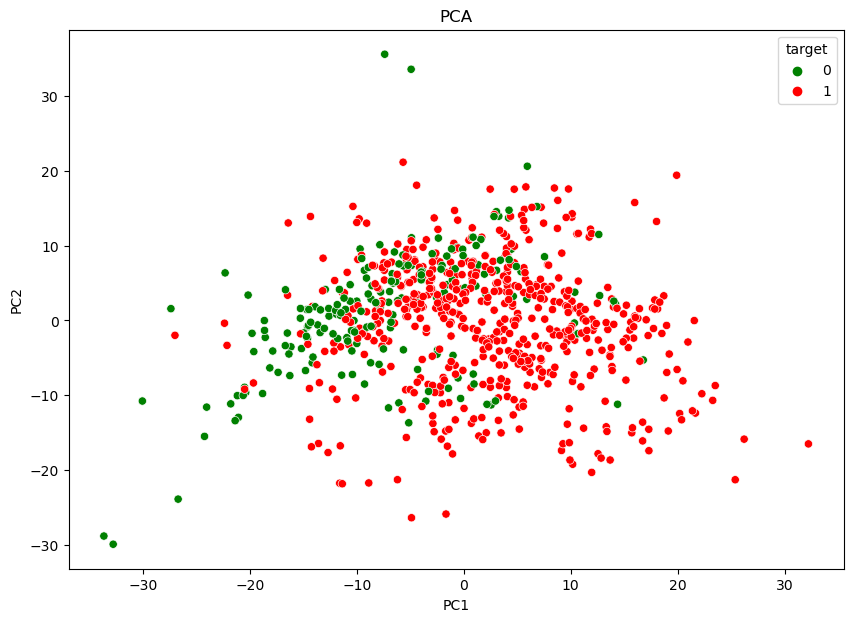

In [7]:
import seaborn as sns
#import pandas as pd

pca = PCA(n_components=2)
principalComponents = pca.fit_transform(X)

# On crée un DataFrame temporaire pour faciliter le traçage
df_pca = pd.DataFrame(data=principalComponents, columns=['PC1', 'PC2'])
df_pca['target'] = y


# Définition de la palette personnalisée
custom_palette = ["green", "red"]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', 
                hue='target', 
                palette=custom_palette)

plt.title('PCA')
plt.show()

# UMAP

In [8]:
import sys

# Clear umap
for key in list(sys.modules.keys()):
    if 'umap' in key:
        del sys.modules[key]

# Import sklearn
import sklearn.utils

# Save original
original = sklearn.utils.check_array

def simple_fix(array, **kwargs):
    try:
        # Try without ensure_all_finite
        kwargs.pop('ensure_all_finite', None)
        return original(array, **kwargs)
    except TypeError as e:
        # If still error, try with minimal params
        return original(array, 
                       dtype=kwargs.get('dtype', 'numeric'),
                       accept_sparse=kwargs.get('accept_sparse', False),
                       ensure_2d=kwargs.get('ensure_2d', True))

sklearn.utils.check_array = simple_fix

# Import umap
#import umap

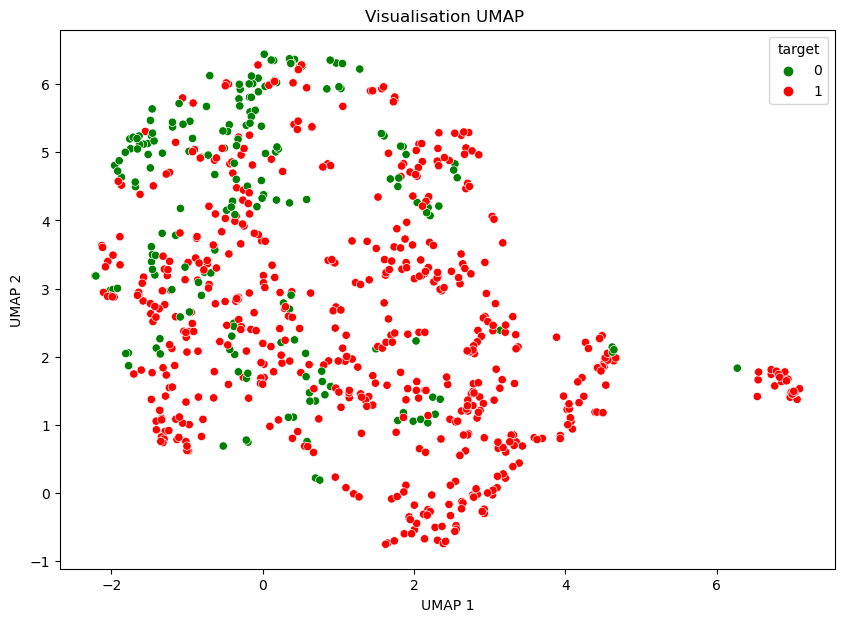

In [9]:
#import seaborn as sns
#import matplotlib.pyplot as plt
reducer = umap.UMAP()
embedding = reducer.fit_transform(X)

# 1. Préparation des données
df_umap = pd.DataFrame(data=embedding, columns=['UMAP 1', 'UMAP 2'])

# 2. On s'assure que target est au format texte pour éviter les conflits de types
df_umap['target'] = y.astype(str) 

# 3. Dictionnaire avec des clés en format texte
couleurs = {"0": "green", "1": "red"}

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_umap, 
    x='UMAP 1', 
    y='UMAP 2', 
    hue='target', 
    palette=couleurs,
    hue_order=["0", "1"] # Force l'ordre dans la légende
)

plt.title("Visualisation UMAP ")
plt.show()

# t-SNE

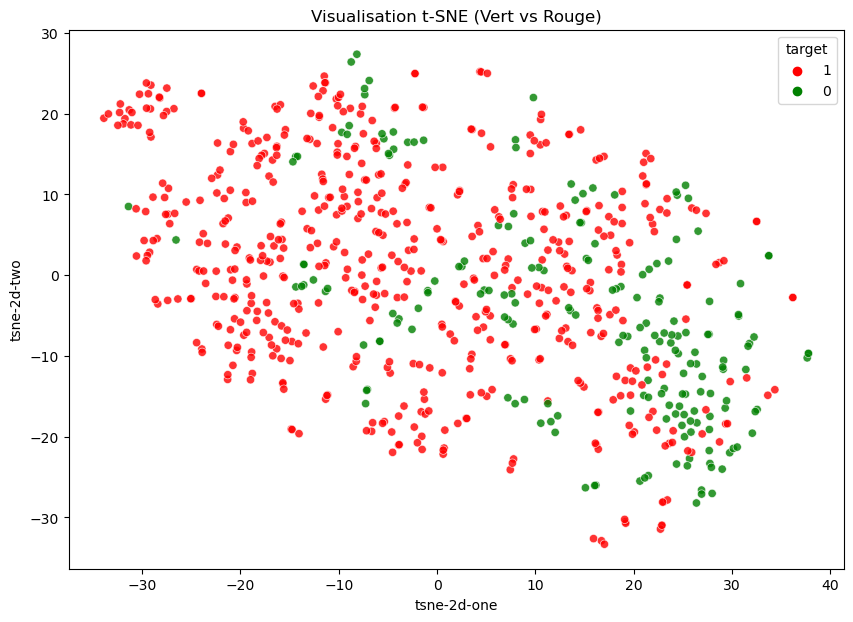

In [10]:
tsne = TSNE(n_components=2, perplexity=40.0)
tsne_result = tsne.fit_transform(X)
#aux.visualize_scatter(tsne_result, y)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1. Calcul du t-SNE
#tsne = TSNE(n_components=2, perplexity=40.0, random_state=42)
#tsne_result = tsne.fit_transform(X)

# 2. Préparation des données dans un DataFrame
df_tsne = pd.DataFrame(data=tsne_result, columns=['tsne-2d-one', 'tsne-2d-two'])

# On convertit y en string pour éviter l'erreur "missing keys"
df_tsne['target'] = pd.Series(y).astype(str).values 

# 3. Définition de la palette (Clés en strings pour correspondre à la conversion)
# '0' sera Vert, '1' sera Rouge
palette_colors = {"0": "green", "1": "red"}

# 4. Visualisation
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_tsne,
    x='tsne-2d-one',
    y='tsne-2d-two',
    hue='target',
    palette=palette_colors,
    alpha=0.8
)

plt.title('Visualisation t-SNE (Vert vs Rouge)')
plt.show()

In [11]:
df.head()

1,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,0,1,0.85247,0.71826,0.57227,240,239,0.008064,0.000087,0.00218,...,1.5620,2.6445,3.8686,4.2105,5.1221,4.4625,2.6202,3.0004,18.9405,1
1,0,1,0.76686,0.69481,0.53966,234,233,0.008258,0.000073,0.00195,...,1.5589,3.6107,23.5155,14.1962,11.0261,9.5082,6.5245,6.3431,45.1780,1
2,0,1,0.85083,0.67604,0.58982,232,231,0.008340,0.000060,0.00176,...,1.5643,2.3308,9.4959,10.7458,11.0177,4.8066,2.9199,3.1495,4.7666,1
3,1,0,0.41121,0.79672,0.59257,178,177,0.010858,0.000183,0.00419,...,3.7805,3.5664,5.2558,14.0403,4.2235,4.6857,4.8460,6.2650,4.0603,1
4,1,0,0.32790,0.79782,0.53028,236,235,0.008162,0.002669,0.00535,...,6.1727,5.8416,6.0805,5.7621,7.7817,11.6891,8.2103,5.0559,6.1164,1


### Cover: Overlapping rectangular bins in the 2D lens space

In [12]:
def build_lens(X, method='PCA', random_state=42):
    method = method.lower()

    if method == 'pca':
        reducer = PCA(n_components=2, random_state=random_state)
        lens = reducer.fit_transform(X)

    elif method == 't-SNE':
        reducer = TSNE(n_components=2, random_state=random_state, perplexity=30)
        lens = reducer.fit_transform(X)

    elif method == 'UMAP':
        reducer = umap.UMAP(n_components=2, random_state=random_state)
        lens = reducer.fit_transform(X)

    return lens                

### Clustering: DBSCAN in standardized voice-feature space

In [13]:
# BUILD MAPPER GRAPH

def build_mapper_graph(X, lens, eps=20.0, min_samples=5, n_cubes=10, perc_overlap=0.4):
    mapper = km.KeplerMapper(verbose=0)
    cover = Cover(n_cubes=n_cubes, perc_overlap=perc_overlap)
    clusterer = DBSCAN(eps=eps, min_samples=min_samples)

    graph = mapper.map(
        lens,
        X,
        cover=cover,
        clusterer=clusterer
    )
    return mapper, graph                      

In [14]:
def mapper_to_networkx(graph):
    G = nx.Graph()
    for node_id, members in graph['nodes'].items():
        G.add_node(node_id, members=members, size=len(members))

    for source, targets in graph['links'].items():
        for target in targets:
            G.add_edge(source, target)

    return G                       


#  NODE STATISTICS

target_col = 'class'

def compute_node_statistics(graph, df, feature_names, target_col='class'):
    rows = []

    for node_id, members in graph['nodes'].items():
        node_df = df.iloc[members]
        n_total = len(node_df)
        n_pd = int((node_df[target_col] == 1).sum())
        n_hc = int((node_df[target_col] == 0).sum())
        pd_ratio = n_pd / n_total if n_total > 0 else np.nan

        row = {
            'node_id': node_id,
            'size': n_total,
            'n_pd': n_pd,
            'n_hc': n_hc,
            'pd_ratio': pd_ratio,
        }

        # Means on original unscaled data
        for col in feature_names:
            row[f'mean__{col}'] = node_df[col].mean()

        rows.append(row)

    return pd.DataFrame(rows)             


# Problem 1: Risk Stratification Based on Node Composition

In [15]:
def solve_problem_1_risk(graph, df, node_stats, target_col='class'):
    L = node_stats['pd_ratio'].dropna().to_numpy()
    Q1 = float(np.percentile(L, 25))
    Q2 = float(np.percentile(L, 50))
    Q3 = float(np.percentile(L, 75))

    node_category = {}
    node_weight = {}
    for _, row in node_stats.iterrows():
        r = row['pd_ratio']
        node_weight[row['node_id']] = int(row['size'])
        if r <= Q1:
            node_category[row['node_id']] = 'Low-Risk'
        elif r >= Q3:
            node_category[row['node_id']] = 'High-Risk'
        else:
            node_category[row['node_id']] = 'Mid-Risk'

    patient_to_nodes = {i: [] for i in range(len(df))}
    for node_id, members in graph['nodes'].items():
        for idx in members:
            patient_to_nodes[idx].append(node_id)

    records = []
    for i in range(len(df)):
        low_score = 0
        mid_score = 0
        high_score = 0

        for node_id in patient_to_nodes[i]:
            w = node_weight[node_id]
            cat = node_category[node_id]
            if cat == 'Low-Risk':
                low_score += w
            elif cat == 'Mid-Risk':
                mid_score += w
            else:
                high_score += w

        if low_score > mid_score and low_score > high_score:
            pred_risk = 'Low-Risk'
        elif high_score > low_score and high_score > mid_score:
            pred_risk = 'High-Risk'
        else:
            pred_risk = 'Mid-Risk'

        truth = int(df.iloc[i][target_col])
        records.append({
            'patient_index': i,
            'truth_class': truth,
            'low_score': low_score,
            'mid_score': mid_score,
            'high_score': high_score,
            'predicted_risk': pred_risk,
        })

    risk_df = pd.DataFrame(records)

    pd_mask = risk_df['truth_class'] == 1
    hc_mask = risk_df['truth_class'] == 0

    pd_high_rate = (risk_df.loc[pd_mask, 'predicted_risk'] == 'High-Risk').mean()
    hc_low_rate = (risk_df.loc[hc_mask, 'predicted_risk'] == 'Low-Risk').mean()
    weighted_accuracy = 0.5 * (pd_high_rate + hc_low_rate)

    print('\n' + '='*70)
    print('PROBLEM 1: RISK STRATIFICATION')
    print('='*70)
    print(f'Q1 = {Q1:.4f}, Q2 = {Q2:.4f}, Q3 = {Q3:.4f}')
    print('\nNode distribution by risk category:')
    print(pd.Series(node_category).value_counts())
    print('\nPatient distribution by predicted risk:')
    print(risk_df['predicted_risk'].value_counts())
    print(f'\n% PD correctly classified as High-Risk: {100*pd_high_rate:.2f}%')
    print(f'% Healthy correctly classified as Low-Risk: {100*hc_low_rate:.2f}%')
    print(f'Weighted accuracy: {100*weighted_accuracy:.2f}%')

    return {
        'Q1': Q1,
        'Q2': Q2,
        'Q3': Q3,
        'risk_df': risk_df,
        'node_category': node_category,
        'pd_high_rate': pd_high_rate,
        'hc_low_rate': hc_low_rate,
        'weighted_accuracy': weighted_accuracy,
    }


In [16]:
lens = build_lens(X, method='PCA', random_state=42)
mapper, graph = build_mapper_graph(X, lens, eps=20.0, min_samples=5, n_cubes=10, perc_overlap=0.4)
note_stats = compute_node_statistics(graph, df, feature_names, target_col='class')
solve_problem_1_risk(graph, df, note_stats, target_col='class')


PROBLEM 1: RISK STRATIFICATION
Q1 = 0.6509, Q2 = 0.8333, Q3 = 0.9101

Node distribution by risk category:
Mid-Risk     13
Low-Risk      7
High-Risk     7
Name: count, dtype: int64

Patient distribution by predicted risk:
predicted_risk
Mid-Risk     651
High-Risk     57
Low-Risk      48
Name: count, dtype: int64

% PD correctly classified as High-Risk: 9.57%
% Healthy correctly classified as Low-Risk: 13.54%
Weighted accuracy: 11.56%


{'Q1': 0.6508771929824562,
 'Q2': 0.8333333333333334,
 'Q3': 0.9100910091009101,
 'risk_df':      patient_index  truth_class  low_score  mid_score  high_score  \
 0                0            1          0         62          99   
 1                1            1          0        131          99   
 2                2            1          0         51          99   
 3                3            1          0          0           0   
 4                4            1          0          0           0   
 ..             ...          ...        ...        ...         ...   
 751            751            0          0          0           0   
 752            752            0          0          0           0   
 753            753            0         98        192           0   
 754            754            0          0        114           0   
 755            755            0          0        114           0   
 
     predicted_risk  
 0        High-Risk  
 1         Mid-Risk  


# Problem 2: Connected Components

In [17]:
def solve_problem_2_components(G, graph, df, feature_names, target_col='class'):
    comps = list(nx.connected_components(G))
    print('\n' + '='*70)
    print('PROBLEM 2: CONNECTED COMPONENTS')
    print('='*70)
    print(f'Number of connected components: {len(comps)}')

    summary_rows = []
    for cid, comp in enumerate(comps, start=1):
        members = []
        for node_id in comp:
            members.extend(graph['nodes'][node_id])
        members = sorted(set(members))
        sub = df.iloc[members]

        row = {
            'component_id': cid,
            'n_nodes': len(comp),
            'n_samples': len(sub),
            'pd_rate': sub[target_col].mean(),
        }

        for col in ['PPE', 'DFA', 'RPDE', 'locPctJitter', 'locShimmer', 'meanHarmToNoiseHarmonicity']:
            if col in sub.columns:
                row[f'mean__{col}'] = sub[col].mean()

        summary_rows.append(row)

    comp_df = pd.DataFrame(summary_rows).sort_values('n_samples', ascending=False)
    print(comp_df)
    return comp_df


In [18]:
G = mapper_to_networkx(graph)
solve_problem_2_components(G, graph, df, feature_names, target_col='class')


PROBLEM 2: CONNECTED COMPONENTS
Number of connected components: 2
   component_id  n_nodes  n_samples   pd_rate  mean__PPE  mean__DFA  \
0             1       26        442  0.794118   0.779089   0.698544   
1             2        1          7  1.000000   0.793690   0.740463   

   mean__RPDE  mean__locPctJitter  mean__locShimmer  \
0    0.463131            0.001858          0.060010   
1    0.535561            0.001274          0.093059   

   mean__meanHarmToNoiseHarmonicity  
0                         19.908523  
1                         17.511429  


,component_id,n_nodes,n_samples,pd_rate,mean__PPE,mean__DFA,mean__RPDE,mean__locPctJitter,mean__locShimmer,mean__meanHarmToNoiseHarmonicity
0,1,26,442,0.794118,0.779089,0.698544,0.463131,0.001858,0.060010,19.908523
1,2,1,7,1.000000,0.793690,0.740463,0.535561,0.001274,0.093059,17.511429


# Problem 3: Node Degree and Hubs

In [19]:
def solve_problem_3_hubs(G, graph, df, target_col='class'):
    degrees = dict(G.degree())
    deg_df = pd.DataFrame({
        'node_id': list(degrees.keys()),
        'degree': list(degrees.values())
    }).sort_values('degree', ascending=False)

    top_hubs = deg_df.head(10).copy()
    pd_ratios = []
    sizes = []
    for node_id in top_hubs['node_id']:
        members = graph['nodes'][node_id]
        node_df = df.iloc[members]
        pd_ratios.append(node_df[target_col].mean())
        sizes.append(len(node_df))
    top_hubs['pd_ratio'] = pd_ratios
    top_hubs['size'] = sizes

    print('\n' + '='*70)
    print('PROBLEM 3: HUBS')
    print('='*70)
    print(top_hubs)

    plt.figure(figsize=(6, 4))
    plt.hist(list(degrees.values()), bins=20, edgecolor='black')
    plt.xlabel('Node degree')
    plt.ylabel('Count')
    plt.title('Node degree distribution')
    plt.grid(True, alpha=0.3)
    plt.show()

    return top_hubs, deg_df


PROBLEM 3: HUBS
            node_id  degree  pd_ratio  size
9   cube33_cluster0       8  0.743590    78
8   cube32_cluster0       8  0.702128    47
15  cube43_cluster0       8  0.900990   101
14  cube42_cluster0       8  0.862500    80
20  cube51_cluster0       8  0.919192    99
7   cube31_cluster0       7  0.818182    33
4   cube23_cluster0       7  0.440678    59
19  cube50_cluster0       7  0.963636    55
10  cube34_cluster0       7  0.701754   114
3   cube22_cluster0       7  0.580645    31


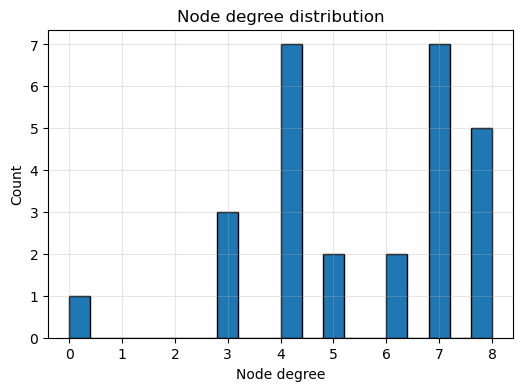

(            node_id  degree  pd_ratio  size
 9   cube33_cluster0       8  0.743590    78
 8   cube32_cluster0       8  0.702128    47
 15  cube43_cluster0       8  0.900990   101
 14  cube42_cluster0       8  0.862500    80
 20  cube51_cluster0       8  0.919192    99
 7   cube31_cluster0       7  0.818182    33
 4   cube23_cluster0       7  0.440678    59
 19  cube50_cluster0       7  0.963636    55
 10  cube34_cluster0       7  0.701754   114
 3   cube22_cluster0       7  0.580645    31,
             node_id  degree
 9   cube33_cluster0       8
 8   cube32_cluster0       8
 15  cube43_cluster0       8
 14  cube42_cluster0       8
 20  cube51_cluster0       8
 7   cube31_cluster0       7
 4   cube23_cluster0       7
 19  cube50_cluster0       7
 10  cube34_cluster0       7
 3   cube22_cluster0       7
 16  cube44_cluster0       7
 13  cube41_cluster0       7
 24  cube59_cluster0       6
 21  cube52_cluster0       6
 5   cube24_cluster0       5
 2   cube21_cluster0       5
 25  cube60

In [20]:
solve_problem_3_hubs(G, graph, df, target_col='class')

# Problem 4: Bridge Nodes and Diagnostic Ambiguity

In [21]:
def solve_problem_4_bridge_nodes(node_stats, risk_results, df, target_col='class'):
    Q1 = risk_results['Q1']
    Q2 = risk_results['Q2']
    Q3 = risk_results['Q3']
    Delta = Q3 - Q1

    def node_type(r):
        if r >= Q3:
            return 'Pure PD'
        elif r <= Q1:
            return 'Pure Healthy'
        elif Q2 < r < Q3:
            return 'PD-skewed'
        elif Q1 <= r < Q2:
            return 'Healthy-skewed'
        elif (Q2 - 0.1*Delta) < r < (Q2 + 0.1*Delta):
            return 'Balanced'
        else:
            return 'Mixed'

    bridge_df = node_stats[['node_id', 'size', 'n_pd', 'n_hc', 'pd_ratio']].copy()
    bridge_df['node_type'] = bridge_df['pd_ratio'].apply(node_type)

    print('\n' + '='*70)
    print('PROBLEM 4: BRIDGE / AMBIGUOUS NODES')
    print('='*70)
    print(bridge_df['node_type'].value_counts())
    print('\nMost mixed nodes:')
    print(bridge_df.iloc[(bridge_df['pd_ratio'] - 0.5).abs().argsort()].head(10))

    return bridge_df

In [22]:
def solve_problem_1_risk(graph, df, node_stats, target_col='class'):
    L = node_stats['pd_ratio'].dropna().to_numpy()
    Q1 = float(np.percentile(L, 25))
    Q2 = float(np.percentile(L, 50))
    Q3 = float(np.percentile(L, 75))

    node_category = {}
    node_weight = {}
    for _, row in node_stats.iterrows():
        r = row['pd_ratio']
        node_weight[row['node_id']] = int(row['size'])
        if r <= Q1:
            node_category[row['node_id']] = 'Low-Risk'
        elif r >= Q3:
            node_category[row['node_id']] = 'High-Risk'
        else:
            node_category[row['node_id']] = 'Mid-Risk'

    patient_to_nodes = {i: [] for i in range(len(df))}
    for node_id, members in graph['nodes'].items():
        for idx in members:
            patient_to_nodes[idx].append(node_id)

    records = []
    for i in range(len(df)):
        low_score = 0
        mid_score = 0
        high_score = 0

        for node_id in patient_to_nodes[i]:
            w = node_weight[node_id]
            cat = node_category[node_id]
            if cat == 'Low-Risk':
                low_score += w
            elif cat == 'Mid-Risk':
                mid_score += w
            else:
                high_score += w

        if low_score > mid_score and low_score > high_score:
            pred_risk = 'Low-Risk'
        elif high_score > low_score and high_score > mid_score:
            pred_risk = 'High-Risk'
        else:
            pred_risk = 'Mid-Risk'

        truth = int(df.iloc[i][target_col])
        records.append({
            'patient_index': i,
            'truth_class': truth,
            'low_score': low_score,
            'mid_score': mid_score,
            'high_score': high_score,
            'predicted_risk': pred_risk,
        })

    risk_df = pd.DataFrame(records)

    pd_mask = risk_df['truth_class'] == 1
    hc_mask = risk_df['truth_class'] == 0

    pd_high_rate = (risk_df.loc[pd_mask, 'predicted_risk'] == 'High-Risk').mean()
    hc_low_rate = (risk_df.loc[hc_mask, 'predicted_risk'] == 'Low-Risk').mean()
    weighted_accuracy = 0.5 * (pd_high_rate + hc_low_rate)

    return {
        'Q1': Q1,
        'Q2': Q2,
        'Q3': Q3,
        'risk_df': risk_df,
        'node_category': node_category,
        'pd_high_rate': pd_high_rate,
        'hc_low_rate': hc_low_rate,
        'weighted_accuracy': weighted_accuracy,
    }


In [23]:
node_stats = compute_node_statistics(graph, df, feature_names, target_col='class')

risk_results = solve_problem_1_risk(graph, df, node_stats, target_col='class')

In [24]:
solve_problem_4_bridge_nodes(node_stats, risk_results, df, target_col='class')


PROBLEM 4: BRIDGE / AMBIGUOUS NODES
node_type
Pure Healthy      7
Pure PD           7
PD-skewed         6
Healthy-skewed    5
Balanced          2
Name: count, dtype: int64

Most mixed nodes:
            node_id  size  n_pd  n_hc  pd_ratio       node_type
4   cube23_cluster0    59    26    33  0.440678    Pure Healthy
5   cube24_cluster0    39    17    22  0.435897    Pure Healthy
0   cube14_cluster0    19     8    11  0.421053    Pure Healthy
17  cube45_cluster0    19    11     8  0.578947    Pure Healthy
3   cube22_cluster0    31    18    13  0.580645    Pure Healthy
11  cube35_cluster0    15     9     6  0.600000    Pure Healthy
10  cube34_cluster0   114    80    34  0.701754  Healthy-skewed
8   cube32_cluster0    47    33    14  0.702128  Healthy-skewed
9   cube33_cluster0    78    58    20  0.743590  Healthy-skewed
16  cube44_cluster0    95    75    20  0.789474  Healthy-skewed


,node_id,size,n_pd,n_hc,pd_ratio,node_type
0,cube14_cluster0,19,8,11,0.421053,Pure Healthy
1,cube15_cluster0,19,3,16,0.157895,Pure Healthy
2,cube21_cluster0,12,10,2,0.833333,Balanced
3,cube22_cluster0,31,18,13,0.580645,Pure Healthy
4,cube23_cluster0,59,26,33,0.440678,Pure Healthy
5,cube24_cluster0,39,17,22,0.435897,Pure Healthy
6,cube30_cluster0,5,5,0,1.000000,Pure PD
7,cube31_cluster0,33,27,6,0.818182,Healthy-skewed
8,cube32_cluster0,47,33,14,0.702128,Healthy-skewed
9,cube33_cluster0,78,58,20,0.743590,Healthy-skewed


# Problem 5: Feature Ranking Using Topological Purity

In [25]:
def compute_feature_risk_score(df, X, y, feature_name, eps=20.0, min_samples=5, n_cubes=10, perc_overlap=0.4):
    feature_index = list(df.columns).index(feature_name) - 2  # adjust for id, gender if using X only? not used below
    lens = X[:, [list(df.columns).index(feature_name) - list(df.columns).tolist().index('PPE')]]
    raise RuntimeError('Use the safer helper below with feature_cols.')

In [26]:
def feature_mapper_score(df, X_scaled, y, feature_names, feature_name, eps=20.0, min_samples=5, n_cubes=10, perc_overlap=0.4):
    idx = feature_names.index(feature_name)
    lens = X[:, [idx]]

    mapper = km.KeplerMapper(verbose=0)
    cover = Cover(n_cubes=n_cubes, perc_overlap=perc_overlap)
    clusterer = DBSCAN(eps=eps, min_samples=min_samples)

    graph = mapper.map(lens, X, cover=cover, clusterer=clusterer)
    if len(graph['nodes']) == 0:
        return None

    node_rows = []
    for node_id, members in graph['nodes'].items():
        yy = y[members]
        r = yy.mean()
        node_rows.append({'node_id': node_id, 'size': len(members), 'pd_ratio': r})
    node_df = pd.DataFrame(node_rows)

    Q1 = np.percentile(node_df['pd_ratio'], 25)
    Q3 = np.percentile(node_df['pd_ratio'], 75)

    node_cat = {}
    node_weight = {}
    for _, row in node_df.iterrows():
        node_weight[row['node_id']] = row['size']
        if row['pd_ratio'] <= Q1:
            node_cat[row['node_id']] = 'Low-Risk'
        elif row['pd_ratio'] >= Q3:
            node_cat[row['node_id']] = 'High-Risk'
        else:
            node_cat[row['node_id']] = 'Mid-Risk'

    patient_to_nodes = {i: [] for i in range(len(df))}
    for node_id, members in graph['nodes'].items():
        for m in members:
            patient_to_nodes[m].append(node_id)

    pred = []
    for i in range(len(df)):
        low_score = 0
        mid_score = 0
        high_score = 0
        for node_id in patient_to_nodes[i]:
            w = node_weight[node_id]
            if node_cat[node_id] == 'Low-Risk':
                low_score += w
            elif node_cat[node_id] == 'Mid-Risk':
                mid_score += w
            else:
                high_score += w

        if low_score > mid_score and low_score > high_score:
            pred.append('Low-Risk')
        elif high_score > low_score and high_score > mid_score:
            pred.append('High-Risk')
        else:
            pred.append('Mid-Risk')

    pred = np.array(pred)
    pd_high_rate = (pred[y == 1] == 'High-Risk').mean()
    hc_low_rate = (pred[y == 0] == 'Low-Risk').mean()
    weighted_accuracy = 0.5 * (pd_high_rate + hc_low_rate)

    return {
        'feature': feature_name,
        'pd_high_rate': pd_high_rate,
        'hc_low_rate': hc_low_rate,
        'weighted_accuracy': weighted_accuracy,
        'n_nodes': len(graph['nodes'])
    }


In [27]:
def solve_problem_5_feature_ranking(df, X, y, feature_names):
    selected_features = [
        # Nonlinear dynamics
        'PPE', 'DFA', 'RPDE', 'det_entropy_shannon_1_coef', 'det_entropy_shannon_2_coef',
        # Jitter
        'locPctJitter', 'locAbsJitter', 'rapJitter', 'ppq5Jitter', 'ddpJitter',
        # Shimmer
        'locShimmer', 'locDbShimmer', 'apq3Shimmer', 'apq5Shimmer', 'apq11Shimmer',
        # Harmonicity / noise
        'meanAutoCorrHarmonicity', 'meanNoiseToHarmHarmonicity', 'meanHarmToNoiseHarmonicity', 'GNE_mean', 'GNE_std',
        # MFCC
        'mean_MFCC_1st_coef', 'mean_MFCC_2nd_coef', 'mean_MFCC_3rd_coef', 'mean_MFCC_4th_coef', 'mean_MFCC_5th_coef'
    ]
    selected_features = [f for f in selected_features if f in feature_names]

    rows = []
    for feat in selected_features:
        try:
            out = feature_mapper_score(df, X, y, feature_names, feat)
            if out is not None:
                rows.append(out)
                print(f'Done: {feat}')
        except Exception as e:
            print(f'Failed: {feat} -> {e}')

    score_df = pd.DataFrame(rows).sort_values('weighted_accuracy', ascending=False)

    # Traditional importance for comparison
    X_sub = df[selected_features]
    rf = RandomForestClassifier(n_estimators=300, random_state=42)
    rf.fit(X_sub, y)
    rf_importance = pd.Series(rf.feature_importances_, index=selected_features)
    mi_importance = pd.Series(mutual_info_classif(X_sub, y, random_state=42), index=selected_features)

    score_df['rf_importance'] = score_df['feature'].map(rf_importance)
    score_df['mi_importance'] = score_df['feature'].map(mi_importance)

    print('\n' + '='*70)
    print('PROBLEM 5: FEATURE RANKING')
    print('='*70)
    print('\nTop 5 features:')
    print(score_df.head(5))
    print('\nBottom 5 features:')
    print(score_df.tail(5))

    return score_df

In [28]:
solve_problem_5_feature_ranking(df, X, y, feature_names)

Done: PPE
Done: DFA
Done: RPDE
Done: det_entropy_shannon_1_coef
Done: det_entropy_shannon_2_coef
Done: locPctJitter
Done: locAbsJitter
Done: rapJitter
Done: ppq5Jitter
Done: ddpJitter
Done: locShimmer
Done: locDbShimmer
Done: apq3Shimmer
Done: apq5Shimmer
Done: apq11Shimmer
Done: meanAutoCorrHarmonicity
Done: meanNoiseToHarmHarmonicity
Done: meanHarmToNoiseHarmonicity
Done: GNE_mean
Done: GNE_std
Done: mean_MFCC_1st_coef
Done: mean_MFCC_2nd_coef
Done: mean_MFCC_3rd_coef
Done: mean_MFCC_4th_coef
Done: mean_MFCC_5th_coef

PROBLEM 5: FEATURE RANKING

Top 5 features:
                       feature  pd_high_rate  hc_low_rate  weighted_accuracy  \
14                apq11Shimmer      0.138298     0.411458           0.274878   
3   det_entropy_shannon_1_coef      0.017730     0.473958           0.245844   
4   det_entropy_shannon_2_coef      0.017730     0.473958           0.245844   
8                   ppq5Jitter      0.017730     0.473958           0.245844   
6                 locAbsJitter

,feature,pd_high_rate,hc_low_rate,weighted_accuracy,n_nodes,rf_importance,mi_importance
14,apq11Shimmer,0.138298,0.411458,0.274878,5,0.059527,0.065372
3,det_entropy_shannon_1_coef,0.017730,0.473958,0.245844,2,0.029768,0.000000
4,det_entropy_shannon_2_coef,0.017730,0.473958,0.245844,2,0.027269,0.008394
8,ppq5Jitter,0.017730,0.473958,0.245844,4,0.038846,0.050940
6,locAbsJitter,0.024823,0.463542,0.244182,4,0.046416,0.056415
5,locPctJitter,0.019504,0.468750,0.244127,5,0.040919,0.050637
16,meanNoiseToHarmHarmonicity,0.017730,0.468750,0.243240,3,0.025468,0.029913
7,rapJitter,0.017730,0.468750,0.243240,3,0.034522,0.039172
9,ddpJitter,0.017730,0.468750,0.243240,3,0.044147,0.052820
15,meanAutoCorrHarmonicity,0.019504,0.463542,0.241523,4,0.024628,0.025674
